<a href="https://colab.research.google.com/github/miamackk/Foundations-Of-Computer-Vision-Code/blob/main/15_Linear_Image_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Systems

The systems that we study here take a signal as input, perform some computation, and output another signal. Linear systems are just a small portion of all the possible systems one could implement, but we will see that they are capable of creating very interesting image transformations. These Linear systems follow this form:

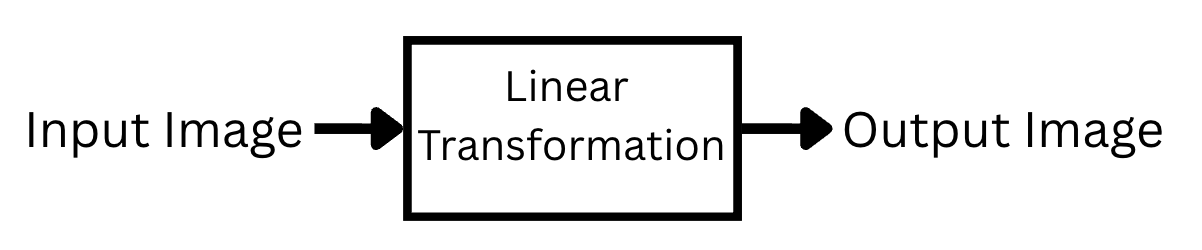

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import convolve
from scipy.ndimage import correlate
import cv2
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

The following folder contains all of the images for this notebook. If you wish to run the code yourself and make changes, make a copy of this folder:
https://drive.google.com/drive/folders/1ipHmCxG3a79JVUWkfd0pGa3xgRbiTFM_?usp=sharing




Run the following code and change the path to route to where you saved the images folder in your drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 15/images/red_block.png')
img = img[:, :, :3]
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


To show this concept, we will be applying four different linear operations on an image of a red block from Chapter 2: Rotation, Scaling, converting to Greyscale, and defocusing (blur). We will use cv2 for these operations!

# Linear Systems: Figure 5.3

Explanation for OpenCV image rotation functions:
https://learnopencv.com/image-rotation-and-translation-using-opencv/#image-rotation

In [ ]:
#ROTATION
theta = 25
scale = 1
width, height = img.shape[0], img.shape[1]
center = (width // 2, height // 2)

#get the rotation matrix
rotation = cv2.getRotationMatrix2D(center, theta, scale)

rotated_img = cv2.warpAffine(img, rotation, (width, height))

Scaling: Explanation on OpenCV image scaling: https://learnopencv.com/image-resizing-with-opencv/

In [ ]:
#SCALING
scaled = cv2.resize(img, (width//2, height//2), interpolation= cv2.INTER_LINEAR)

width_new, height_new = scaled.shape[0], scaled.shape[1]

#pad the outside of our downscaled image for displaying
padded = np.pad(scaled, ((width_new//2, height_new//2),(width_new//2, height_new//2),(0,0)))

Greyscale:

In [ ]:
#GREYSCALE

#numpy makes it easy, as we can just sum along axis 2, collapsing the color channels by summing them all together while preserving pixel location
#Then we divide every value by 3 to get average

avg = np.sum(img, axis=2)/3

Blur: Refresher for image blurring: https://opencv.org/blog/image-filtering-using-convolution-in-opencv/#h-blurring-an-image

In [ ]:
#DEFOCUS (BLUR)

r, g, b = cv2.split(img)

blur_filter = np.ones((13,13), dtype = np.float32)/169.0

r_blur = convolve(r, blur_filter)
g_blur = convolve(g, blur_filter)
b_blur = convolve(b, blur_filter)

blurred_image = cv2.merge((r_blur, g_blur, b_blur))


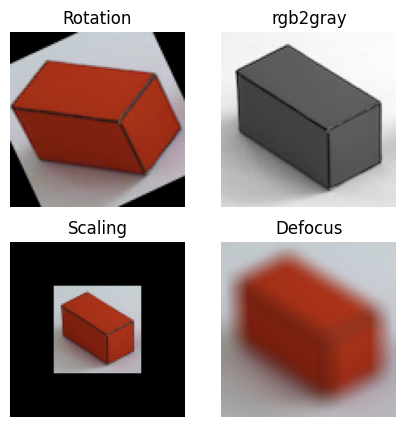

In [ ]:
plt.figure(figsize=(5,5))
titles = ["Rotation", "rgb2gray", "Scaling", "Defocus"]
images = [rotated_img, avg, padded, blurred_image]

for i in range(4):
  plt.subplot(2, 2, i+1)
  if titles[i]=="rgb2gray":
    plt.imshow(images[i], cmap="gray")
  else:
    plt.imshow(images[i])
  plt.title(titles[i])
  plt.axis("off")

# Convolution: Figure 15.9

In [ ]:
a_filter = np.array([[0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 1, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0]])

b_filter = np.array([[0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0]])

c_filter = np.array([[.5, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0],
                     [0, 0, 0, 0, .5]])

d_filter = np.array([[1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1]])/25

r_a = convolve(r, a_filter, mode="constant", cval=0)
g_a = convolve(g, a_filter, mode="constant", cval=0)
b_a = convolve(b, a_filter, mode="constant", cval=0)
figure_a = cv2.merge((r_a, g_a, b_a))

r_b = convolve(r, b_filter, mode="constant", cval=0)
g_b = convolve(g, b_filter, mode="constant", cval=0)
b_b = convolve(b, b_filter, mode="constant", cval=0)
figure_b = cv2.merge((r_b, g_b, b_b))
# figure_b[:,0,:]=0

r_c = convolve(r, c_filter, mode="constant", cval=0)
g_c = convolve(g, c_filter, mode="constant", cval=0)
b_c = convolve(b, c_filter, mode="constant", cval=0)
figure_c = cv2.merge((r_c, g_c, b_c))

r_d = convolve(r, d_filter, mode="constant", cval=0)
g_d = convolve(g, d_filter, mode="constant", cval=0)
b_d = convolve(b, d_filter, mode="constant", cval=0)
figure_d = cv2.merge((r_d, g_d, b_d))



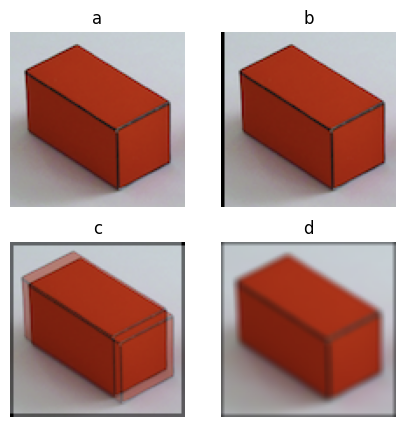

In [ ]:
# @title
plt.figure(figsize=(5,5))

titles = ["a", "b", "c", "d"]
figures = [figure_a, figure_b, figure_c, figure_d]

for i in range(4):
  plt.subplot(2, 2, i+1)
  plt.imshow(figures[i])
  plt.title(titles[i])
  plt.axis("off")


# Handling Edges: Figure 15.10

When using convolution, if we want to keep the original image size, we need to extend beyond the dimensions of the input image. To do this we "pad" the image, or add extra pixels past the boundary of the original image.Ideally, we would to get a result that is a close as possible to the output we would get if we had access to a larger image. Some methods that the book shows are: Zero padding, circular padding, mirror padding, and repeat padding. These methods are shown below

In [ ]:
# @title
ground_truth = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 15/images/padding_example.png')
ground_truth = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)

head = ground_truth[280:560, 280:560, :]
width, height = head.shape[0], head.shape[1]


In [ ]:
#use np.pad for different padding methods

zero_pad_example = np.pad(head, ((width, height),(width, height),(0,0)))
mirror_example = np.pad(head, ((width, height),(width, height),(0,0)), mode = "symmetric")
circular_example = np.pad(head, ((width, height),(width, height),(0,0)), mode = "wrap")
repeat_example = np.pad(head, ((width, height),(width, height),(0,0)), mode = "edge")

In [ ]:
#create blurring filter, pad zebra head with correct amount of padding (5px for 11x11 filter)
#split into rgb channels to preserve color, convolve each channel and then merge together

blur_kernel = np.ones((11,11), dtype=np.float32)/121.0

zero = np.pad(head, ((5, 5),(5, 5),(0,0)))
r, g, b = convolve(zero[:,:,0], blur_kernel), convolve(zero[:,:,1], blur_kernel), convolve(zero[:,:,2], blur_kernel)
blur_zero = cv2.merge((r, g, b))

mirror = np.pad(head, ((5, 5),(5, 5),(0,0)), mode = "symmetric")
r, g, b = convolve(mirror[:,:,0], blur_kernel), convolve(mirror[:,:,1], blur_kernel), convolve(mirror[:,:,2], blur_kernel)
blur_mirror = cv2.merge((r, g, b))

circular = np.pad(head, ((5, 5),(5, 5),(0,0)), mode = "wrap")
r, g, b = convolve(circular[:,:,0], blur_kernel), convolve(circular[:,:,1], blur_kernel), convolve(circular[:,:,2], blur_kernel)
blur_circular = cv2.merge((r, g, b))

repeat = np.pad(head, ((5, 5),(5, 5),(0,0)), mode = "edge")
r, g, b = convolve(repeat[:,:,0], blur_kernel), convolve(repeat[:,:,1], blur_kernel), convolve(repeat[:,:,2], blur_kernel)
blur_repeat = cv2.merge((r, g, b))

r, g, b = convolve(ground_truth[275:565, 275:565, 0], blur_kernel), convolve(ground_truth[275:565, 275:565, 1], blur_kernel), convolve(ground_truth[275:565, 275:565, 2], blur_kernel)
blur_truth = cv2.merge((r, g, b))

In [ ]:
#subtract and normalize for last row of the figure
def subtract(img, ground_truth=blur_truth):
    diff = np.abs(img.astype(float) - ground_truth.astype(float))
    # print(diff.shape)

    if diff.max() > 0:
        diff_norm = diff / diff.max()
        diff_display = np.clip((diff_norm * 350), 0, 255).astype(np.uint8)
    else:
        diff_display = np.zeros_like(diff, dtype=np.uint8)

    return np.pad(diff_display, ((3, 3),(3, 3),(0,0)), mode = "edge")

(np.float64(-0.5), np.float64(289.5), np.float64(289.5), np.float64(-0.5))

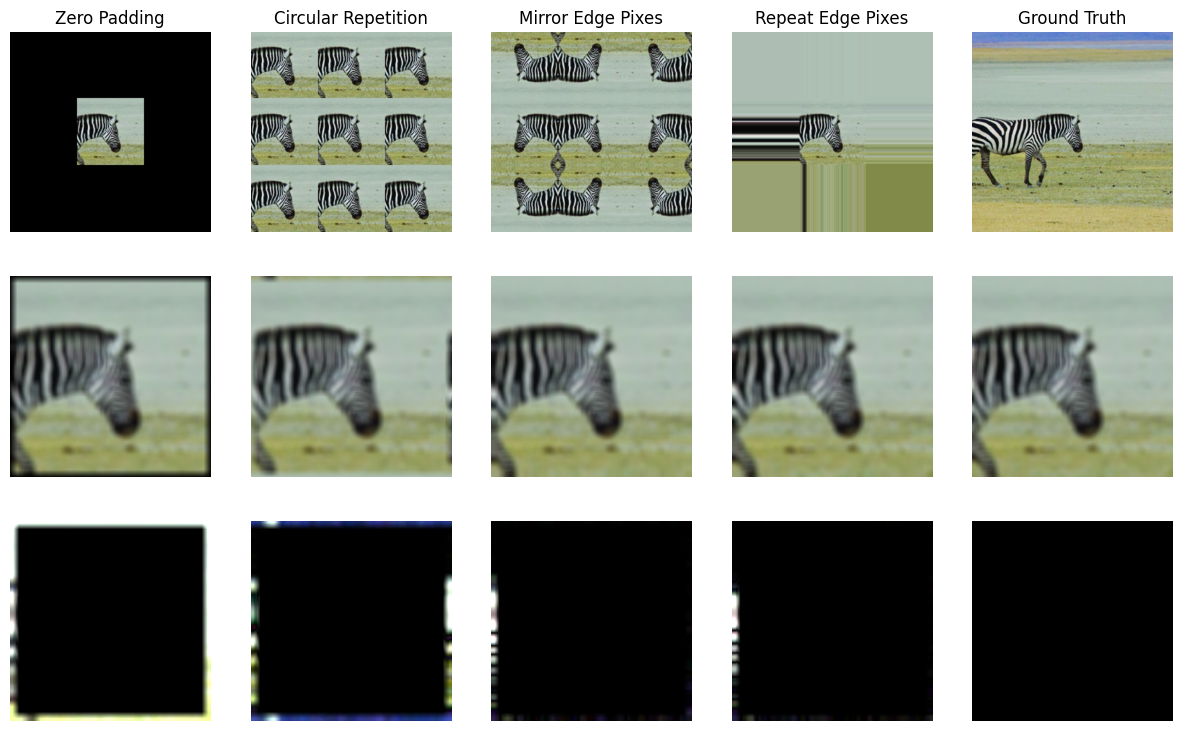

In [ ]:
# @title Plot All Images
plt.figure(figsize=(15,9))
plt.axis("off")

#first row (Each row shows different types of boundary extension. The last image shows the ground truth)
plt.subplot(3, 5, 1)
plt.imshow(zero_pad_example)
plt.title("Zero Padding")
plt.axis("off")

plt.subplot(3, 5, 2)
plt.imshow(circular_example)
plt.title("Circular Repetition")
plt.axis("off")

plt.subplot(3, 5, 3)
plt.imshow(mirror_example)
plt.title("Mirror Edge Pixes")
plt.axis("off")

plt.subplot(3, 5, 4)
plt.imshow(repeat_example)
plt.title("Repeat Edge Pixes")
plt.axis("off")

plt.subplot(3, 5, 5)
plt.imshow(ground_truth)
plt.title("Ground Truth")
plt.axis("off")

#second row (output of convolving the image with a uniform kernel of size (11, 11) with all the values equal to (1/121)

plt.subplot(3, 5, 6)
plt.imshow(blur_zero)
plt.axis("off")

plt.subplot(3, 5, 7)
plt.imshow(blur_circular)
plt.axis("off")

plt.subplot(3, 5, 8)
plt.imshow(blur_mirror)
plt.axis("off")

plt.subplot(3, 5, 9)
plt.imshow(blur_repeat)
plt.axis("off")

plt.subplot(3, 5, 10)
plt.imshow(blur_truth)
plt.axis("off")

#third row (difference between each output and ground truth output)

plt.subplot(3, 5, 11)
plt.imshow(subtract(blur_zero))
plt.axis("off")

plt.subplot(3, 5, 12)
plt.imshow(subtract(blur_circular))
plt.axis("off")

plt.subplot(3, 5, 13)
plt.imshow(subtract(blur_mirror))
plt.axis("off")

plt.subplot(3, 5, 14)
plt.imshow(subtract(blur_repeat))
plt.axis("off")

plt.subplot(3, 5, 15)
plt.imshow(np.abs(blur_truth-blur_truth))
plt.axis("off")

# Convolution vs Cross Correlation: Figure 15.11

In [ ]:
#load in input images and the kernel
img1 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 15/images/input1.png', cv2.IMREAD_GRAYSCALE)
img1= (img1/255.0).astype(np.float32)

img2 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 15/images/input2.png', cv2.IMREAD_GRAYSCALE)
img2= (img2/255.0).astype(np.float32)

filter = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 15/images/kernel.png', cv2.IMREAD_GRAYSCALE)
filter= (filter/255.0).astype(np.float32)

In [ ]:
convolution1 = convolve(img1, filter)
correlation1 = correlate(img1, filter)

convolution2 = convolve(img2, filter)
correlation2 = correlate(img2, filter)

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

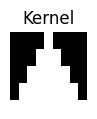

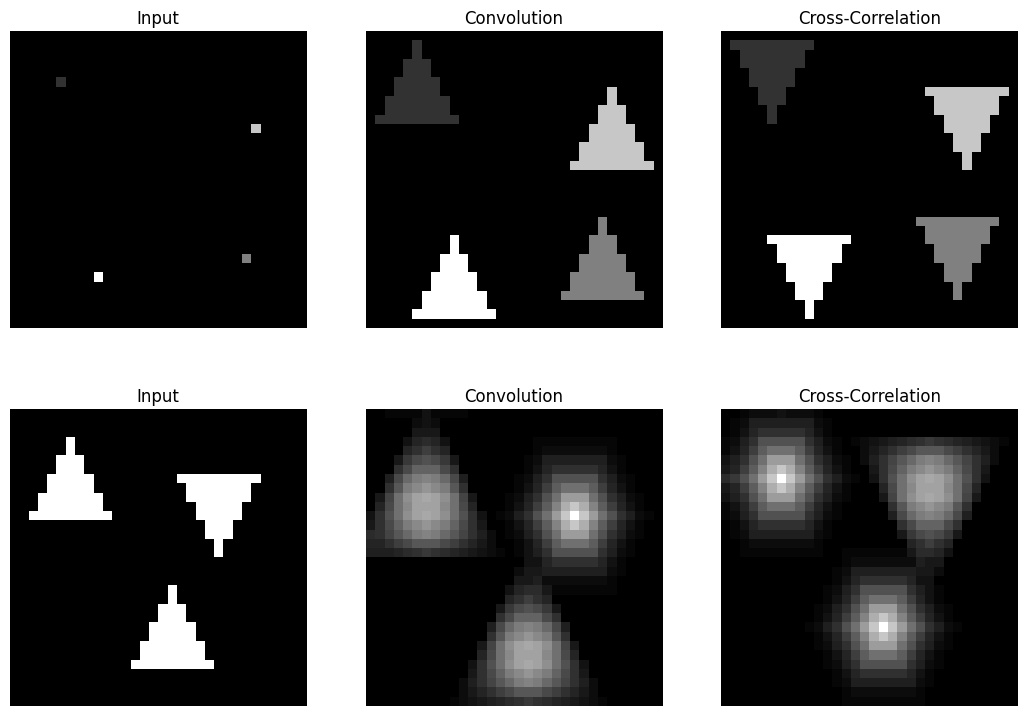

In [ ]:
# @title
plt.figure(figsize=(1,1))
plt.title("Kernel")
plt.axis("off")
plt.imshow(filter, cmap="gray")

plt.figure(figsize=(13,9))
plt.axis("off")

#first row
plt.subplot(2, 3, 1)
plt.title("Input")
plt.imshow(img1, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Convolution")
plt.imshow(convolution1, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Cross-Correlation")
plt.imshow(correlation1, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Input")
plt.imshow(img2, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Convolution")
plt.imshow(convolution2, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Cross-Correlation")
plt.imshow(correlation2, cmap="gray")
plt.axis("off")


